In [199]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_squared_error
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [200]:
df = pd.read_csv("indian_patient_records.zip")
df = df.dropna()
df.head()
df["Dataset"].value_counts()

Dataset
1    414
2    165
Name: count, dtype: int64

In [201]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [202]:
scaler = MinMaxScaler()
X = df.drop(columns = ["Gender", "Dataset"])
y = df.Dataset
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=0,stratify=y)

knn = KNeighborsClassifier(n_neighbors=2)  # You can choose the number of neighbors (k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [204]:
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Model Evaluation:
Accuracy: 0.7241379310344828
Confusion Matrix:
[[114  10]
 [ 38  12]]
Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.92      0.83       124
           2       0.55      0.24      0.33        50

    accuracy                           0.72       174
   macro avg       0.65      0.58      0.58       174
weighted avg       0.69      0.72      0.68       174



É melhor o segundo modelo porque é preciso identificar corretamente se os pacientes estão doentes ou não

O 1º

In [205]:
df = pd.read_csv("iris_flower_dataset.zip")
df = df.dropna()
setosa = df[df['species'] == 'Iris-setosa']
versicolor = df[df['species'] == 'Iris-versicolor']
virginica = df[df['species'] == 'Iris-virginica']
set_len = setosa['sepal_length'].values
set_wid = setosa['sepal_width'].values
ver_len = versicolor['sepal_length'].values
ver_wid = versicolor['sepal_width'].values
vir_len = virginica['sepal_length'].values
vir_wid = virginica['sepal_width'].values

/tmp/ipykernel_45281/3573463050.py:4: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(ver_len, ver_wid, label='Versicolor', alpha=0.6, edgecolors='w', s=100, c='green', marker='x')


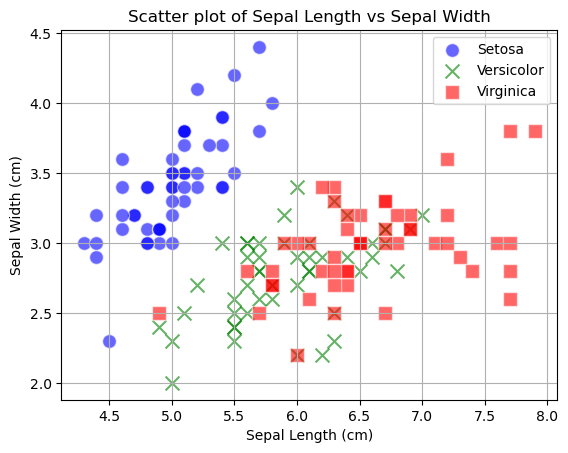

In [206]:
import matplotlib.pyplot as plt

plt.scatter(set_len, set_wid, label='Setosa', alpha=0.6, edgecolors='w',s=100, c='blue', marker='o')
plt.scatter(ver_len, ver_wid, label='Versicolor', alpha=0.6, edgecolors='w', s=100, c='green', marker='x')
plt.scatter(vir_len, vir_wid, label='Virginica', alpha=0.6, edgecolors='w', s=100, c='red', marker='s')

plt.title('Scatter plot of Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()

less misclassifications = class setosa

In [235]:
scaler = MinMaxScaler()
scaler2 = StandardScaler()
X = df[["sepal_length", "sepal_width"]]
y = df.species

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
knn = KNeighborsClassifier(n_neighbors=2)
#X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = scaler2.fit_transform(X_train)
knn.fit(X_train_scaled, y_train)
#X_test_scaled = scaler.transform(X_test)
X_test_scaled = scaler2.transform(X_test)
y_pred = knn.predict(X_test_scaled)

In [236]:
print(confusion_matrix(y_test, y_pred))
print("Accuracy: ",accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[[11  0  0]
 [ 0 10  3]
 [ 0  4  2]]
Accuracy:  0.7666666666666667
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.71      0.77      0.74        13
 Iris-virginica       0.40      0.33      0.36         6

       accuracy                           0.77        30
      macro avg       0.70      0.70      0.70        30
   weighted avg       0.76      0.77      0.76        30



k = 2 dá o melhor valor com standartização e/ou normalização.
k = 4 é o melhor valor sem standardização e normalização

Com normalização e standartização e 2 vizinhos

In [237]:
X = df.drop(columns=['species'])
y = df.species
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
knn2 = KNeighborsClassifier(n_neighbors=2)
knn2.fit(X_train, y_train)
y_pred = knn2.predict(X_test)

In [238]:
print(confusion_matrix(y_test, y_pred))
print("Accuracy: ",accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]
Accuracy:  0.9666666666666667
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.83      0.91         6

       accuracy                           0.97        30
      macro avg       0.98      0.94      0.96        30
   weighted avg       0.97      0.97      0.97        30

